In [32]:
import os
import glob
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [33]:
wifi_path = "Datasets/WiFi dataset"
mag_path = "Datasets/Magnetic field dataset"

print("WiFi folder exists:", os.path.exists(wifi_path))
print("Magnetic folder exists:", os.path.exists(mag_path))

WiFi folder exists: True
Magnetic folder exists: True


In [34]:
wifi_files = glob.glob("Datasets/WiFi dataset/**/*.csv", recursive=True)
mag_files = glob.glob("Datasets/Magnetic field dataset/**/*.csv", recursive=True)

print("Total WiFi files:", len(wifi_files))
print("Total Magnetic files:", len(mag_files))

Total WiFi files: 2831
Total Magnetic files: 4261


In [35]:
sample_wifi_file = wifi_files[0]
print(sample_wifi_file)

Datasets/WiFi dataset\BE Engineering\Navigation\Scenario-1\A8\User 2\WiFi_BE Building_Scenario 1_User 2 (M-174cm)_Navigation_2021.05.19 171520.csv


In [36]:
with open(sample_wifi_file, "rb") as f:
    print(f.read(200))

b'\xd0\xcf\x11\xe0\xa1\xb1\x1a\xe1\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00>\x00\x03\x00\xfe\xff\t\x00\x06\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x00\x00\x007\x00\x00\x00\x00\x00\x00\x00\x00\x10\x00\x00\xfe\xff\xff\xff\x00\x00\x00\x00\xfe\xff\xff\xff\x00\x00\x00\x006\x00\x00\x00\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff'


In [37]:
df_wifi = pd.read_excel(sample_wifi_file)

df_wifi.head()

,Time,X-pos,Y-pos,SSID,BSSID,RSS
0,2021:05:19 17:15:20,1.0,24.0,WAP5089,00:1a:be:a0:de:89,-53
1,NaN,NaN,NaN,WAP5144,00:1a:be:a0:df:45,-53
2,NaN,NaN,NaN,WAP5146,00:1a:be:a0:df:47,-56
3,NaN,NaN,NaN,WAP5091,00:1a:be:a0:de:91,-57
4,NaN,NaN,NaN,WAP5090,00:1a:be:a0:de:90,-61


In [38]:
df_wifi.shape

(37, 6)

In [39]:
df_wifi.columns

Index(['Time', 'X-pos', 'Y-pos', 'SSID', 'BSSID', 'RSS'], dtype='object')

In [40]:
df_wifi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    1 non-null      object 
 1   X-pos   1 non-null      float64
 2   Y-pos   1 non-null      float64
 3   SSID    37 non-null     object 
 4   BSSID   37 non-null     object 
 5   RSS     37 non-null     int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 1.9+ KB


In [41]:
df_wifi.isnull().sum()

Time     36
X-pos    36
Y-pos    36
SSID      0
BSSID     0
RSS       0
dtype: int64

In [42]:
df_wifi["RSS"].describe()

count    37.000000
mean    -75.189189
std      10.823939
min     -90.000000
25%     -84.000000
50%     -78.000000
75%     -66.000000
max     -53.000000
Name: RSS, dtype: float64

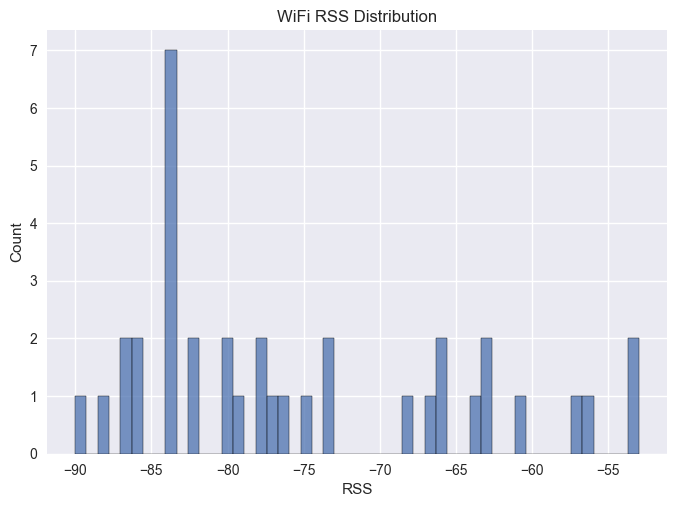

In [43]:
sns.histplot(df_wifi["RSS"], bins=50)
plt.title("WiFi RSS Distribution")
plt.show()

In [44]:
df_wifi["BSSID"].nunique()

37

In [45]:
ap_counts = df_wifi.groupby("Time")["BSSID"].count()

ap_counts.describe()

count    1.0
mean     1.0
std      NaN
min      1.0
25%      1.0
50%      1.0
75%      1.0
max      1.0
Name: BSSID, dtype: float64

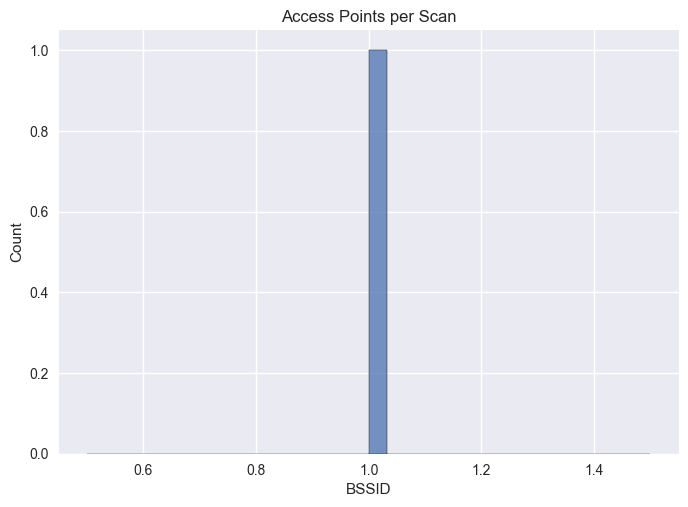

In [46]:
sns.histplot(ap_counts, bins=30)
plt.title("Access Points per Scan")
plt.show()

In [47]:
sample_mag_file = mag_files[0]

print(sample_mag_file)

Datasets/Magnetic field dataset\Continuous Data\BE Building\Navigation\Scenario 1\A8\User 2\IMU_BE Building_Scenario 1_User 2 (M-174cm)_Navigation_2021.05.19 173743.csv


In [48]:
df_mag = pd.read_csv(sample_mag_file)

df_mag.head()

,Time,Mag_x,Mag_y,Mag_z,Acc_x,Acc_y,Acc_z,Gyro_x,Gyro_y,Gyro_z,Orn_x,Orn_y,Orn_z,Pressure
0,2021.05.19 17:37:43,32.820000,-13.320000,-26.340000,-0.481235,0.931344,9.543288,0.003665,0.090408,0.103847,-0.097161,0.050384,-1.894290,1004.03784
1,2021.05.19 17:37:43,33.000000,-13.559999,-26.400000,0.090980,1.331176,9.612720,-0.076969,-0.136223,0.218079,-0.137599,-0.009464,-1.858915,1004.03784
2,2021.05.19 17:37:43,33.120000,-13.440000,-26.340000,-0.538695,1.290475,9.311050,-0.001222,-0.064141,0.133779,-0.137492,0.057791,-1.861784,1004.03784
3,2021.05.19 17:37:43,33.059998,-13.200000,-26.099998,-0.507571,1.359907,9.502586,0.015272,-0.153327,0.080023,-0.141944,0.053363,-1.851907,1004.09230
4,2021.05.19 17:37:43,32.700000,-13.679999,-25.619999,-0.632069,1.661576,9.392453,-0.007330,-0.143553,0.054978,-0.174707,0.067194,-1.843602,1004.09230


In [49]:
df_mag["Mag_magnitude"] = np.sqrt(
    df_mag["Mag_x"]**2 +
    df_mag["Mag_y"]**2 +
    df_mag["Mag_z"]**2
)

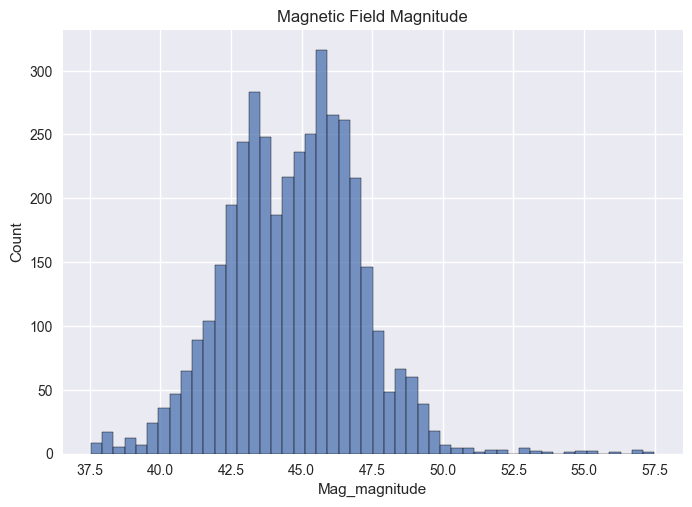

In [50]:
sns.histplot(df_mag["Mag_magnitude"], bins=50)
plt.title("Magnetic Field Magnitude")
plt.show()

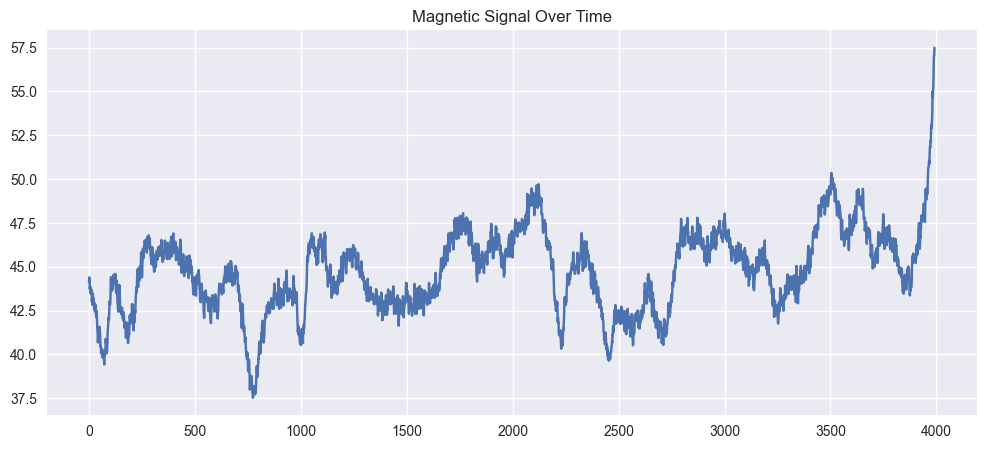

In [51]:
df_mag["Mag_magnitude"].plot(figsize=(12,5))
plt.title("Magnetic Signal Over Time")
plt.show()

In [52]:
wifi_root = "Datasets/WiFi dataset"

wifi_files = []

for root, dirs, files in os.walk(wifi_root):
    for file in files:
        if file.endswith(".csv"):
            wifi_files.append(os.path.join(root, file))

print("Total WiFi files:", len(wifi_files))


Total WiFi files: 2831


In [53]:
wifi_files[:5]


['Datasets/WiFi dataset\\BE Engineering\\Navigation\\Scenario-1\\A8\\User 2\\WiFi_BE Building_Scenario 1_User 2 (M-174cm)_Navigation_2021.05.19 171520.csv',
 'Datasets/WiFi dataset\\BE Engineering\\Navigation\\Scenario-1\\A8\\User 2\\WiFi_BE Building_Scenario 1_User 2 (M-174cm)_Navigation_2021.05.19 171534.csv',
 'Datasets/WiFi dataset\\BE Engineering\\Navigation\\Scenario-1\\A8\\User 2\\WiFi_BE Building_Scenario 1_User 2 (M-174cm)_Navigation_2021.05.19 171547.csv',
 'Datasets/WiFi dataset\\BE Engineering\\Navigation\\Scenario-1\\A8\\User 2\\WiFi_BE Building_Scenario 1_User 2 (M-174cm)_Navigation_2021.05.19 171602.csv',
 'Datasets/WiFi dataset\\BE Engineering\\Navigation\\Scenario-1\\A8\\User 2\\WiFi_BE Building_Scenario 1_User 2 (M-174cm)_Navigation_2021.05.19 171732.csv']

In [54]:
ap_set = set()

for file in wifi_files[:100]:   # start small
    df = pd.read_excel(file)
    ap_set.update(df["BSSID"].unique())

print("Unique APs across dataset:", len(ap_set))

Unique APs across dataset: 164


In [55]:
rss_values = []

for file in wifi_files[:200]:
    df = pd.read_excel(file)
    rss_values.extend(df["RSS"].values)

print("RSS min:", min(rss_values))
print("RSS max:", max(rss_values))

RSS min: -95
RSS max: 0


In [56]:
zero_count = 0
total_count = 0

for file in wifi_files[:200]:
    df = pd.read_excel(file)
    zero_count += (df["RSS"] == 0).sum()
    total_count += len(df)

print("Zero RSS count:", zero_count)
print("Total RSS values:", total_count)
print("Zero percentage:", zero_count / total_count)

Zero RSS count: 6
Total RSS values: 7186
Zero percentage: 0.0008349568605622043


In [57]:
df["RSS"] = df["RSS"].replace(0, -100)